# Fusión de datos y análisis de contratación (`y`)

Fusionamos `customer-details.xlsx` (perfil del cliente) con `Datos_Limpios.csv` (campaña de marketing bancario)
usando la clave común `ID` / `id_`. Con el dataset fusionado, analizamos la variable objetivo `y`
(si el cliente contrató el depósito) en relación con:

1. `Kidhome` y `Teenhome`
2. `Income`
3. Antigüedad del cliente (calculada a partir de `Dt_Customer`)


## 1. Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Cargar y fusionar los datasets

In [2]:
# Customer details: 3 hojas por año
hojas = pd.read_excel("customer-details.xlsx", sheet_name=None)
for nombre, d in hojas.items():
    d["Anio"] = nombre
customer_details = pd.concat(hojas.values(), ignore_index=True)
customer_details = customer_details.drop(columns=[c for c in customer_details.columns if c.startswith("Unnamed")])

# Datos de la campaña de marketing, ya limpios
datos_limpios = pd.read_csv("Datos_Limpios.csv")
datos_limpios = datos_limpios.drop(columns=[c for c in datos_limpios.columns if c.startswith("Unnamed")])

print("customer_details:", customer_details.shape)
print("datos_limpios:", datos_limpios.shape)

customer_details: (43170, 7)
datos_limpios: (42285, 24)


In [3]:
# Fusión por la clave común ID / id_
df = customer_details.merge(datos_limpios, left_on="ID", right_on="id_", how="inner")
df = df.drop(columns=["id_"])

print("Dataset fusionado:", df.shape)
df.head()

Dataset fusionado: (42285, 30)


,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,Anio,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,grupo_edad
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,2012,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,2019-08-02,41.495,-71.233,NaN
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,2012,57.0,services,MARRIED,high.school,0.0,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,0.000,5191.0,no,2016-09-14,34.601,-83.923,46-60
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2012,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191.0,no,2019-02-15,34.939,-94.847,31-45
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,2012,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,93.994,-36.4,0.000,5191.0,no,2015-11-29,49.041,-70.308,31-45
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2012,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,93.994,-36.4,0.000,5191.0,no,2017-01-29,38.033,-104.463,46-60


**Nota:** usamos `how="inner"` porque nos interesa analizar `y`, que solo existe para los clientes que
participaron en la campaña. Esto deja 42,285 clientes (de los 43,170 originales de `customer-details`).

## 3. Vista general de la variable objetivo `y`

In [4]:
df['y'].value_counts()

y
no     37530
yes     4755
Name: count, dtype: int64

## 4. `y` vs. `Kidhome` y `Teenhome`

In [5]:
# Tasa de contratación (% de 'yes') por cantidad de hijos/adolescentes en el hogar
tasa_kidhome = df.groupby('Kidhome')['y'].apply(lambda s: (s == 'yes').mean())
tasa_teenhome = df.groupby('Teenhome')['y'].apply(lambda s: (s == 'yes').mean())

comparativa_hogar = pd.DataFrame({
    'Kidhome': tasa_kidhome,
    'Teenhome': tasa_teenhome
})
comparativa_hogar

,Kidhome,Teenhome
0,0.113122,0.113324
1,0.110552,0.110860
2,0.113680,0.113177


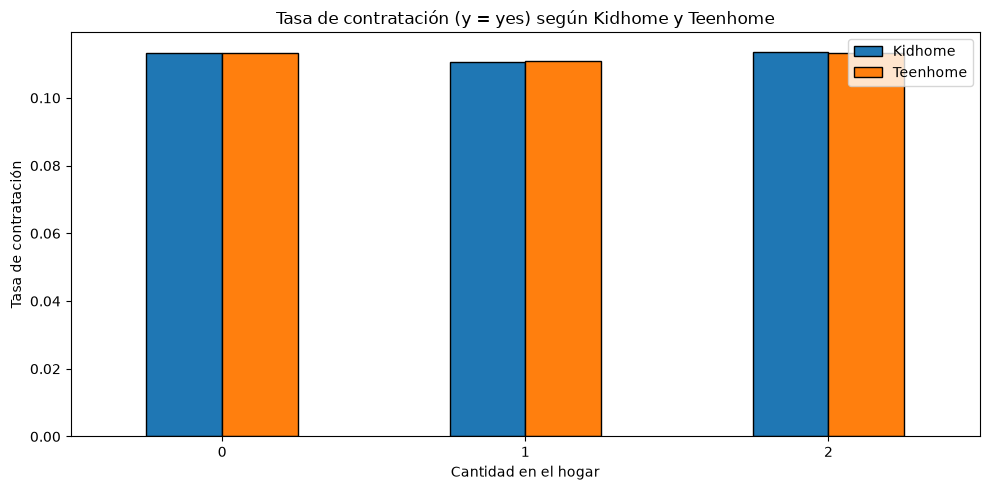

In [6]:
comparativa_hogar.plot(kind='bar', edgecolor='black')
plt.title('Tasa de contratación (y = yes) según Kidhome y Teenhome')
plt.xlabel('Cantidad en el hogar')
plt.ylabel('Tasa de contratación')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. `y` vs. `Income`

In [7]:
bins = [0, 20000, 40000, 60000, 80000, 100000, 120000, 140000, 160000, 180000, df['Income'].max() + 1]
labels = ['0-20k', '20-40k', '40-60k', '60-80k', '80-100k',
          '100-120k', '120-140k', '140-160k', '160-180k', '180k+']
df['IncomeBin'] = pd.cut(df['Income'], bins=bins, labels=labels, right=False)

tasa_income = df.groupby('IncomeBin', observed=True)['y'].apply(lambda s: (s == 'yes').mean())
tasa_income

IncomeBin
0-20k       0.107652
20-40k      0.117611
40-60k      0.110790
60-80k      0.117217
80-100k     0.115117
100-120k    0.118270
120-140k    0.107258
140-160k    0.105296
160-180k    0.111204
180k+       0.121951
Name: y, dtype: float64

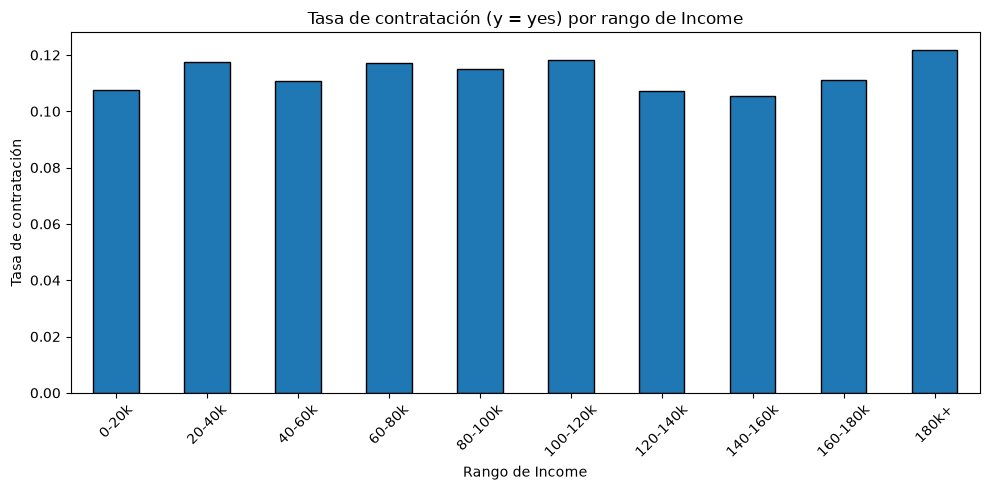

In [8]:
tasa_income.plot(kind='bar', edgecolor='black')
plt.title('Tasa de contratación (y = yes) por rango de Income')
plt.xlabel('Rango de Income')
plt.ylabel('Tasa de contratación')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. `y` vs. Antigüedad del cliente

Calculamos la antigüedad en días a partir de `Dt_Customer`, tomando como referencia el día posterior
a la fecha de alta más reciente del dataset.

In [9]:
referencia = df['Dt_Customer'].max() + pd.Timedelta(days=1)
df['Antiguedad_dias'] = (referencia - df['Dt_Customer']).dt.days

df[['Dt_Customer', 'Antiguedad_dias']].head()

,Dt_Customer,Antiguedad_dias
0,2012-04-04,1002
1,2012-12-30,732
2,2012-02-02,1064
3,2012-12-21,741
4,2012-06-20,925


In [10]:
bins_antiguedad = [0, 200, 400, 600, 800, 1000, df['Antiguedad_dias'].max() + 1]
labels_antiguedad = ['0-200', '200-400', '400-600', '600-800', '800-1000', '1000+']
df['AntiguedadBin'] = pd.cut(df['Antiguedad_dias'], bins=bins_antiguedad, labels=labels_antiguedad, right=False)

tasa_antiguedad = df.groupby('AntiguedadBin', observed=True)['y'].apply(lambda s: (s == 'yes').mean())
tasa_antiguedad

AntiguedadBin
0-200       0.219989
200-400     0.221912
400-600     0.073697
600-800     0.063954
800-1000    0.042937
1000+       0.051570
Name: y, dtype: float64

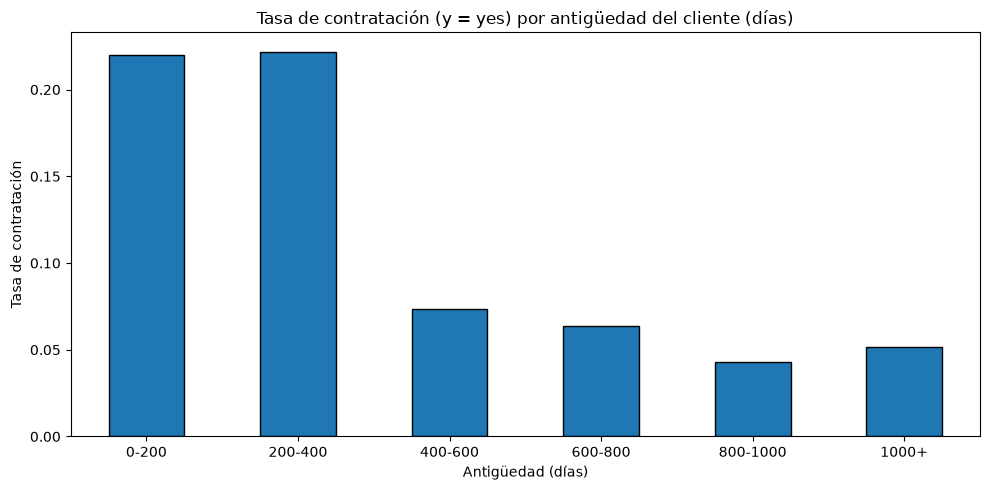

In [11]:
tasa_antiguedad.plot(kind='bar', edgecolor='black')
plt.title('Tasa de contratación (y = yes) por antigüedad del cliente (días)')
plt.xlabel('Antigüedad (días)')
plt.ylabel('Tasa de contratación')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Profundizando en clientes con antigüedad ≤ 400 días

Este grupo mostró una tasa de contratación mucho más alta (~22%) que el resto (~5-7%). Para entender por qué,
comparamos 4 variables entre los clientes con antigüedad ≤ 400 días y el resto (`> 400 días`).

In [16]:
df['Grupo_antiguedad'] = df['Antiguedad_dias'].apply(lambda x: '<=400' if x <= 400 else '>400')
comparativa_previo = pd.DataFrame({
    'previous (promedio contactos)': df.groupby('Grupo_antiguedad')['previous'].mean(),
    '% nunca contactado antes (pdays=999)': df.groupby('Grupo_antiguedad')['pdays'].apply(lambda s: (s == 999).mean())
})
comparativa_previo

,previous (promedio contactos),% nunca contactado antes (pdays=999)
Grupo_antiguedad,,
<=400,0.436279,0.896940
>400,0.035561,0.998264


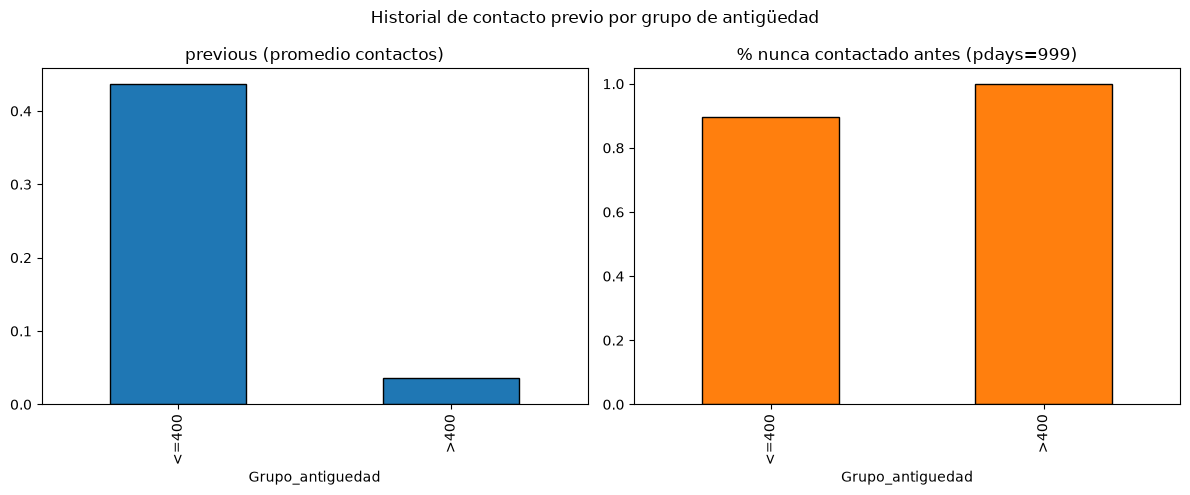

In [17]:
comparativa_previo.plot(kind='bar', edgecolor='black', subplots=True, legend=False, layout=(1, 2), figsize=(12, 5))
plt.suptitle('Historial de contacto previo por grupo de antigüedad')
plt.tight_layout()
plt.show()

**Lectura:** los clientes con antigüedad ≤ 400 días tienen en promedio muchos más contactos previos
(0.44 vs. 0.04) y casi el 90% de ellos ya había sido contactado antes (contra prácticamente el 100% de
"nunca contactado" en el grupo de más antigüedad). Esto sugiere que este grupo no es solo "más nuevo" en
`Dt_Customer`, sino que también arrastra un historial de campañas previas mucho más activo.

### 8 Tipo de contacto (`contact`)

In [ ]:
contact_por_grupo = pd.crosstab(df['Grupo_antiguedad'], df['contact'], normalize='index')
contact_por_grupo

contact,cellular,telephone
Grupo_antiguedad,,
<=400,0.866753,0.133247
>400,0.514995,0.485005


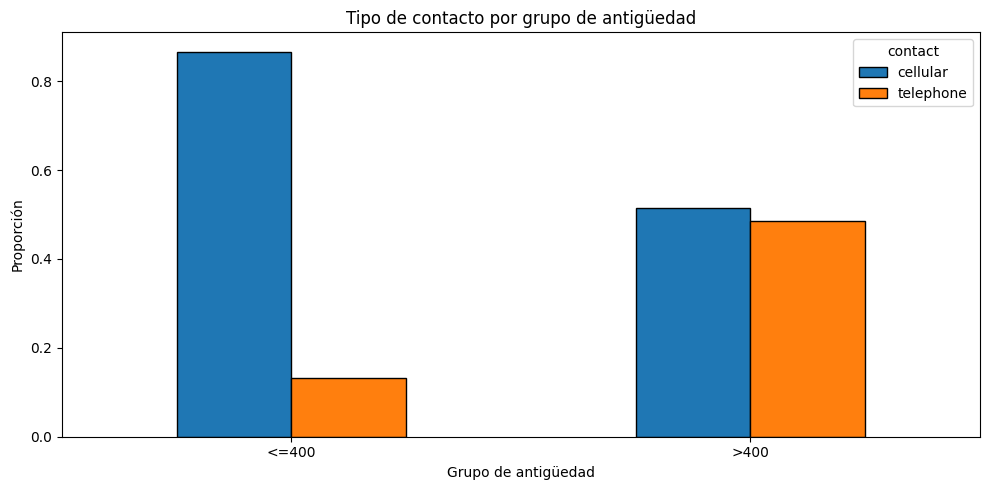

In [ ]:
contact_por_grupo.plot(kind='bar', edgecolor='black')
plt.title('Tipo de contacto por grupo de antigüedad')
plt.xlabel('Grupo de antigüedad')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()